# 06 Business Insights & Recommendations

## Objective

The objective of this notebook is to summarize the business insights obtained from the customer churn analysis and convert the analytical findings into actionable business recommendations.

This notebook combines:

- Exploratory Data Analysis (EDA)
- SQL Analysis
- Statistical Analysis
- Machine Learning Results

to answer key business questions and estimate the potential business impact of reducing customer churn.

---

## Business Questions

1. What is the current churn rate?
2. How much monthly revenue is lost because of churn?
3. Which customer segments are most likely to churn?
4. Which services contribute most to churn?
5. Which customers should be targeted first for retention?
6. What business actions should management take?

---

## Expected Outcome

By the end of this notebook, stakeholders should understand:

- Major churn drivers
- High-risk customer segments
- Estimated revenue impact
- Customer retention opportunities
- Strategic business recommendations

CUSTOMER CHURN BUSINESS INSIGHTS
Total Customers                : 7043
Retained Customers             : 5174
Churned Customers              : 1869
Overall Churn Rate             : 26.54%
Total Monthly Revenue          : $456,116.60
Monthly Revenue Lost           : $139,130.85
Revenue Loss Percentage        : 30.50%


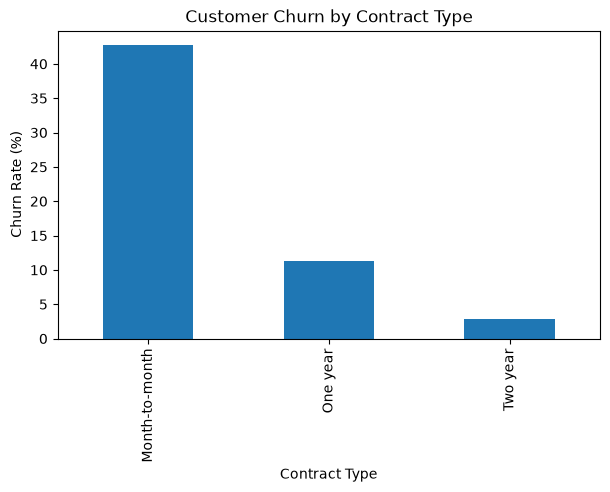


Insight 1
Month-to-month customers have the highest churn rate.
Recommendation: Promote long-term contracts through discounts and loyalty benefits.


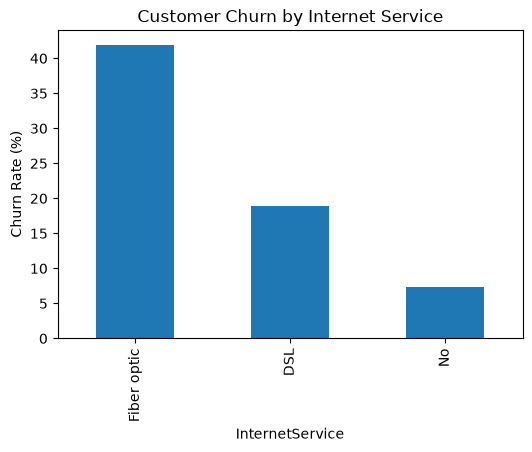


Insight 2
Fiber Optic customers churn significantly more than DSL customers.
Recommendation: Improve service quality and customer support for Fiber Optic users.


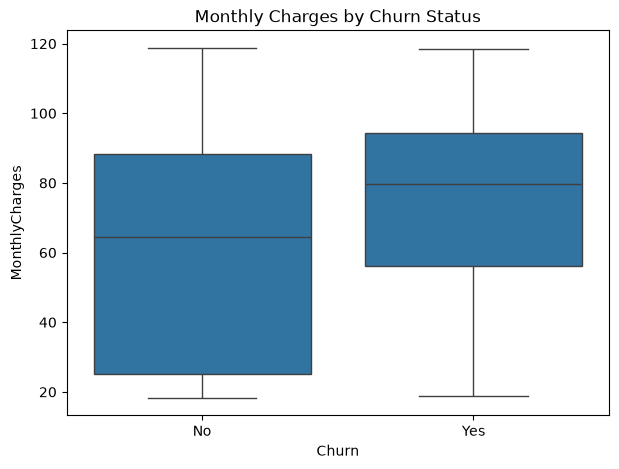


Insight 3
Customers paying higher monthly charges are more likely to churn.
Recommendation: Offer personalized pricing plans or bundled discounts.


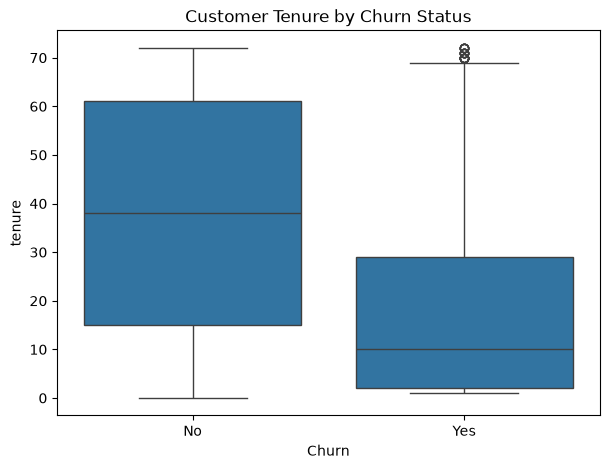


Insight 4
Customers with lower tenure are much more likely to churn.
Recommendation: Strengthen onboarding and engagement during the first year.

High-RRisk Customers Identified : 383


,customerID,Contract,tenure,MonthlyCharges,TotalCharges,InternetService,PaymentMethod
31,4929-XIHVW,Month-to-month,2,95.50,181.65,Fiber optic,Credit card (automatic)
44,4080-IIARD,Month-to-month,13,76.20,981.45,DSL,Electronic check
65,5122-CYFXA,Month-to-month,3,75.30,244.10,DSL,Electronic check
69,7410-OIEDU,Month-to-month,10,79.85,887.35,Fiber optic,Mailed check
85,4445-ZJNMU,Month-to-month,9,99.30,918.75,Fiber optic,Credit card (automatic)
91,2424-WVHPL,Month-to-month,1,74.70,74.70,Fiber optic,Electronic check
115,3071-VBYPO,Month-to-month,3,89.85,248.40,Fiber optic,Electronic check
130,2876-GZYZC,Month-to-month,13,85.95,1215.65,Fiber optic,Electronic check
155,6551-GNYDG,Month-to-month,14,80.90,1152.80,Fiber optic,Bank transfer (automatic)
178,5947-SGKCL,Month-to-month,15,105.35,1559.25,Fiber optic,Bank transfer (automatic)



ESTIMATED BUSINESS IMPACT
If churn is reduced by 5%
Customers Retained            : 93
Monthly Revenue Saved         : $6,956.54
Annual Revenue Saved          : $83,478.51

FINAL BUSINESS RECOMMENDATIONS


,Priority,Recommendation
0,1,Promote long-term contracts
1,2,Improve Fiber Optic customer experience
2,3,Target high monthly charge customers
3,4,Retain customers during first-year onboarding
4,5,Deploy ML model for proactive churn prediction



PROJECT CONCLUSION
--------------------------------------------------------------------------------

The analysis indicates that customer churn is primarily influenced by:

• Contract Type
• Monthly Charges
• Customer Tenure
• Internet Service

Statistical hypothesis testing confirmed significant relationships
between customer characteristics and churn.

Machine Learning models can identify high-risk customers before
they leave, enabling proactive retention campaigns.

Implementing the recommended strategies could improve customer
retention while protecting recurring revenue.

Business Insights Notebook Completed Successfully


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================================
# Load Dataset
# ==========================================================

df = pd.read_csv("../data/processed/cleaned_telco_churn.csv")

print("="*80)
print("CUSTOMER CHURN BUSINESS INSIGHTS")
print("="*80)

# ==========================================================
# Executive Summary
# ==========================================================

total_customers = len(df)

churned_customers = len(df[df["Churn"] == "Yes"])

retained_customers = len(df[df["Churn"] == "No"])

churn_rate = churned_customers / total_customers * 100

monthly_revenue = df["MonthlyCharges"].sum()

monthly_revenue_lost = df[df["Churn"] == "Yes"]["MonthlyCharges"].sum()

revenue_loss_percentage = (
    monthly_revenue_lost / monthly_revenue
) * 100

print(f"Total Customers                : {total_customers}")
print(f"Retained Customers             : {retained_customers}")
print(f"Churned Customers              : {churned_customers}")
print(f"Overall Churn Rate             : {churn_rate:.2f}%")
print(f"Total Monthly Revenue          : ${monthly_revenue:,.2f}")
print(f"Monthly Revenue Lost           : ${monthly_revenue_lost:,.2f}")
print(f"Revenue Loss Percentage        : {revenue_loss_percentage:.2f}%")

# ==========================================================
# Insight 1 - Contract Type
# ==========================================================

contract_churn = (
    df.groupby("Contract")["ChurnFlag"]
      .mean()
      .sort_values(ascending=False) * 100
)

plt.figure(figsize=(7,4))

contract_churn.plot(kind="bar")

plt.title("Customer Churn by Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xlabel("Contract Type")

plt.show()

print("\nInsight 1")
print("Month-to-month customers have the highest churn rate.")
print("Recommendation: Promote long-term contracts through discounts and loyalty benefits.")

# ==========================================================
# Insight 2 - Internet Service
# ==========================================================

internet_churn = (
    df.groupby("InternetService")["ChurnFlag"]
      .mean()
      .sort_values(ascending=False) * 100
)

plt.figure(figsize=(6,4))

internet_churn.plot(kind="bar")

plt.title("Customer Churn by Internet Service")
plt.ylabel("Churn Rate (%)")

plt.show()

print("\nInsight 2")
print("Fiber Optic customers churn significantly more than DSL customers.")
print("Recommendation: Improve service quality and customer support for Fiber Optic users.")

# ==========================================================
# Insight 3 - Monthly Charges
# ==========================================================

plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges by Churn Status")

plt.show()

print("\nInsight 3")
print("Customers paying higher monthly charges are more likely to churn.")
print("Recommendation: Offer personalized pricing plans or bundled discounts.")

# ==========================================================
# Insight 4 - Tenure
# ==========================================================

plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x="Churn",
    y="tenure"
)

plt.title("Customer Tenure by Churn Status")

plt.show()

print("\nInsight 4")
print("Customers with lower tenure are much more likely to churn.")
print("Recommendation: Strengthen onboarding and engagement during the first year.")

# ==========================================================
# Insight 5 - High Risk Customers
# ==========================================================

high_risk = df[
    (df["Contract"]=="Month-to-month") &
    (df["MonthlyCharges"]>=70) &
    (df["tenure"]<=18) &
    (df["Churn"]=="No")
]

print("\nHigh-RRisk Customers Identified :", len(high_risk))

display(
    high_risk[
        [
            "customerID",
            "Contract",
            "tenure",
            "MonthlyCharges",
            "TotalCharges",
            "InternetService",
            "PaymentMethod"
        ]
    ].head(20)
)

# ==========================================================
# Estimated Business Impact
# ==========================================================

avg_monthly_revenue = (
    df[df["Churn"]=="Yes"]["MonthlyCharges"].mean()
)

estimated_customers_saved = churned_customers * 0.05

estimated_monthly_revenue_saved = (
    estimated_customers_saved *
    avg_monthly_revenue
)

estimated_annual_revenue_saved = (
    estimated_monthly_revenue_saved * 12
)

print("\n" + "="*80)
print("ESTIMATED BUSINESS IMPACT")
print("="*80)

print(f"If churn is reduced by 5%")
print(f"Customers Retained            : {estimated_customers_saved:.0f}")
print(f"Monthly Revenue Saved         : ${estimated_monthly_revenue_saved:,.2f}")
print(f"Annual Revenue Saved          : ${estimated_annual_revenue_saved:,.2f}")

# ==========================================================
# Final Recommendations
# ==========================================================

recommendations = pd.DataFrame({
    "Priority":[1,2,3,4,5],
    "Recommendation":[
        "Promote long-term contracts",
        "Improve Fiber Optic customer experience",
        "Target high monthly charge customers",
        "Retain customers during first-year onboarding",
        "Deploy ML model for proactive churn prediction"
    ]
})

print("\n" + "="*80)
print("FINAL BUSINESS RECOMMENDATIONS")
print("="*80)

display(recommendations)

# ==========================================================
# Project Conclusion
# ==========================================================

print("\nPROJECT CONCLUSION")
print("-"*80)

print("""
The analysis indicates that customer churn is primarily influenced by:

• Contract Type
• Monthly Charges
• Customer Tenure
• Internet Service

Statistical hypothesis testing confirmed significant relationships
between customer characteristics and churn.

Machine Learning models can identify high-risk customers before
they leave, enabling proactive retention campaigns.

Implementing the recommended strategies could improve customer
retention while protecting recurring revenue.
""")

print("="*80)
print("Business Insights Notebook Completed Successfully")
print("="*80)